<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M11_A_13_Generative__AI_Essentials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 13: Generative AI Essentials
#Name Ayleen Santander

#Dataset Preparation:
1. Dataset Choice: URL Project Gutenberg (http://www.gutenberg.org/)

In [1]:
#Step 1: Set the enviroment
!pip install transformers torch
import torch
import torchvision
import requests, re
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torch.nn import functional as F
from torch import nn
import torch, torch.nn as nn, numpy as np
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import AutoTokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import set_seed
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math, torch

In [2]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
model.eval()
set_seed(42)
print("Model loaded.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded.


In [3]:
#Step2: Load that from URL
def load_gutenberg(book_id):
  url=f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
  r= requests.get(url, headers={'User-Agent': "Mozilla/5.0"})
  r.raise_for_status()
  text=r.text

  #Trim the Project Gutenberg header/footer
  start=re.search(r'\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG.*?\*\*', text)
  end= re.search(r'\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG.*?\*\*', text)
  if start: text = text[start.end():]
  if end: text=text[:end.start()]
  return text.strip()
text = load_gutenberg(1342) #Pride and Prejudice
print(len(text), 'characters')
print(text[:500])

744279 characters
*




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                                   ]




                                P


In [4]:
#Chunked into training blocks:
tok= AutoTokenizer.from_pretrained('gpt2')
ids=tok(text)['input_ids']

block=128
chunks= [ids[i:i+block] for i in range(0, len(ids)- block, block)]
print(len(chunks), 'chunks')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (206816 > 1024). Running this sequence through the model will result in indexing errors


1615 chunks


In [5]:
#keep the info in the cache(files in the cache)
import nltk; nltk.download("gutenberg")
from nltk.corpus import gutenberg
print(gutenberg.fileids())
text = gutenberg.raw("austen-emma.txt")

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


In [33]:
# #Step 3: Load the pre-trained model and tokenizer
model_name = 'gpt2'
model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [49]:
#Transformer load
model = AutoModelForCausalLM.from_pretrained("gpt2", attn_implementation="eager")
model.eval()
print('attn impl', model.config._attn_implementation)   # should now say 'eager'

with torch.no_grad():
    out = model(**inputs, output_attentions=True)

print(len(out.attentions), out.attentions[0].shape)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

attn impl eager
12 torch.Size([1, 12, 8, 8])


In [50]:
##Check reference for slicing it
layer, head = 0, 0
A = out.attentions[layer][0, head]   # (8, 8) matrix
print(A.sum(dim=-1))                 # each row sums to ~1

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


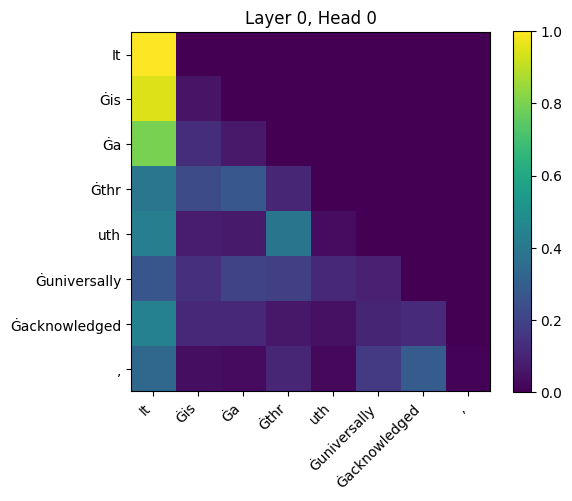

In [51]:
#plot it
tokens = tok.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(6, 5))
plt.imshow(A.numpy(), cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.title(f"Layer {layer}, Head {head}")
plt.tight_layout()
plt.show()

In [52]:
#Define a function for text generation
def generate_text(prompt, max_length=100):
  input_ids = tokenizer.encode(prompt, return_tensors='pt')
  output = model.generate(input_ids, max_length=max_length, num_return_sequences=1, pad_token_id=tokenizer.eos_token_id)
  generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
  return generated_text

In [53]:
#Define generated text
tokenizer = AutoTokenizer.from_pretrained('gpt2')
model = AutoModelForCausalLM.from_pretrained('gpt2')

def generate_text(prompt, max_length=150):
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [54]:
#Check acctually in memory
[v for v in dir()if not v.startswith('_')]

['A',
 'AutoModelForCausalLM',
 'AutoTokenizer',
 'DataLoader',
 'F',
 'GPT2LMHeadModel',
 'GPT2Tokenizer',
 'In',
 'MNIST',
 'Out',
 'attn_p',
 'block',
 'cfg',
 'chunk',
 'chunks',
 'emb_p',
 'exit',
 'generate_text',
 'generated_text',
 'get_ipython',
 'gutenberg',
 'head',
 'i',
 'ids',
 'inputs',
 'layer',
 'load_gutenberg',
 'math',
 'mlp_p',
 'model',
 'model_name',
 'nltk',
 'nn',
 'np',
 'out',
 'output',
 'pd',
 'perplexity',
 'plt',
 'prompt',
 'quit',
 're',
 'requests',
 'sample',
 'set_seed',
 'sns',
 't',
 'temp',
 'text',
 'tok',
 'tokenizer',
 'tokens',
 'torch',
 'torchvision',
 'transforms']

In [55]:
#Experiment with different prompts and parameters
#Exeercise 1:
set_seed(42)
prompt = "Pride and Prejudice"
generated_text = generate_text(prompt, max_length=150)
print(generated_text)

Pride and Prejudice: What Can a Christian Do About Hate Speech? (Oxford University Press, 2012), 8–11.

[1] D. C. White, "Race, Culture and Politics in the United States," American Sociological Review, vol. 44, no. 2, pp. 1146–1148, 2012.

[2] H. H. C. White, "The Politics of Hate Speech," American Sociological Review, vol. 45, no. 2, pp. 1155–1159, 2012.

[3] D. C. White, "Race, Culture and Politics in the United States," American Sociological Review, vol. 45, no. 2


In [56]:
#Exercise 2:
for temp in [0.3, 0.7, 1.2]:
  set_seed(42)
  print(f'---temperature={temp}---')
  inputs=tokenizer("It is a thruth universally acknowledged,", return_tensors='pt')
  output=model.generate(**inputs, max_new_tokens=60, do_sample=True, temperature=temp, top_p=0.9, pad_token_id=tokenizer.eos_token_id)
  print(tokenizer.decode(output[0], skip_special_tokens=True), '\n')

---temperature=0.3---
It is a thruth universally acknowledged, and one that is not only accepted, but accepted by many. It is a thruth that is not only accepted, but accepted by many.

The thruth is the one that is not only accepted, but accepted by many.

The thruth is the one that is not only 

---temperature=0.7---
It is a thruth universally acknowledged, that there is a vast difference in the degree of the degree of the increase of the rate of increase. The former increase is the greater, the latter decrease is less. There is no difference between the two. The increase of the rate of increase is the greater, the decrease is less. The difference 

---temperature=1.2---
It is a thruth universally acknowledged, that there is a vast difference in the two parts: A-tension and B-tension. The former does not give itself much trouble because it cannot be crossed into both. Thus A-tension would mean a condition of separation from both and it can only be crossed from a B- 



In [57]:
#Diagnose the text is
print(type(text), len(text))
print(repr(text[:200]))

<class 'str'> 887071
'[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCHAPTER I\n\n\nEmma Woodhouse, handsome, clever, and rich, with a comfortable home\nand happy disposition, seemed to unite some of the best blessings\nof existence; an'


In [58]:
#Reassing the text
text = gutenberg.raw("austen-emma.txt")
print(len(text))

887071


In [59]:
def perplexity(txt):
    enc = tokenizer(txt, return_tensors="pt", truncation=True, max_length=1024)
    with torch.no_grad():
        return torch.exp(model(**enc, labels=enc["input_ids"]).loss).item()

print(f"Emma (real prose):  {perplexity(text[5000:8000]):.2f}")
print(f"Shuffled nonsense:  {perplexity('zxq blorp ktrm vlan wug pfth nexil bram'):.2f}")
print(f"Modern slang:       {perplexity('no cap that fit is bussin fr fr ong'):.2f}")

Emma (real prose):  36.18
Shuffled nonsense:  899.80
Modern slang:       1332.91


In [60]:
#Training objective measure on the corpus
chunk = tokenizer(text[5000:8000], return_tensors="pt",
                  truncation=True, max_length=1024)
with torch.no_grad():
    out = model(**chunk, labels=chunk["input_ids"])
print(f"Loss: {out.loss.item():.4f}  Perplexity: {torch.exp(out.loss).item():.2f}")

Loss: 3.5885  Perplexity: 36.18


#Part 2: Exploring Generative Pre-trained Transformers (GPTs):
1. Model Architecture

In [61]:
#Describe the architecture of GPTs, focussing on aspects such as tre transfomer model
#Architecture: inspect the actual numbers/transformer model
cfg = model.config
print(f"Decoder blocks (layers):  {cfg.n_layer}")
print(f"Attention heads per layer: {cfg.n_head}")
print(f"Embedding dimension:      {cfg.n_embd}")
print(f"Dimensions per head:      {cfg.n_embd // cfg.n_head}")
print(f"Max context length:       {cfg.n_positions}")
print(f"Vocabulary size:          {cfg.vocab_size}")
print(f"Total parameters:         {sum(p.numel() for p in model.parameters()):,}")

print("\n--- Structure of one decoder block ---")
print(model.transformer.h[0])

attn_p = sum(p.numel() for n,p in model.named_parameters() if ".attn." in n)
mlp_p  = sum(p.numel() for n,p in model.named_parameters() if ".mlp." in n)
emb_p  = model.transformer.wte.weight.numel() + model.transformer.wpe.weight.numel()
print(f"\nAttention params:    {attn_p:,}")
print(f"Feed-forward params: {mlp_p:,}")
print(f"Embedding params:    {emb_p:,}")

Decoder blocks (layers):  12
Attention heads per layer: 12
Embedding dimension:      768
Dimensions per head:      64
Max context length:       1024
Vocabulary size:          50257
Total parameters:         124,439,808

--- Structure of one decoder block ---
GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

Attention params:    28,348,416
Feed-forward params: 56,669,184
Embedding params:    39,383,808


In [62]:
#Tokenization(BPE)
sample = "It is a truth universally acknowledged, that a single man in possession of a good fortune"
ids = tokenizer(sample)["input_ids"]
print(f"{len(sample)} characters -> {len(ids)} tokens\n")
for t, i in zip(tokenizer.convert_ids_to_tokens(ids), ids):
    print(f"  {t:<18} {i}")

89 characters -> 17 tokens

  It                 1026
  Ġis                318
  Ġa                 257
  Ġtruth             3872
  Ġuniversally       26208
  Ġacknowledged      10810
  ,                  11
  Ġthat              326
  Ġa                 257
  Ġsingle            2060
  Ġman               582
  Ġin                287
  Ġpossession        7797
  Ġof                286
  Ġa                 257
  Ġgood              922
  Ġfortune           15807


In [66]:
model = AutoModelForCausalLM.from_pretrained("gpt2",
    attn_implementation="eager"   # required to expose attention weights
)
model.eval()
print("attn impl:", model.config._attn_implementation)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

attn impl: eager


In [72]:
#forward pass so out is rebuilt with teh current model
with torch.no_grad():
    out = model(**inputs, output_attentions=True)

print(len(out.attentions), out.attentions[0].shape)

12 torch.Size([1, 12, 8, 8])


In [73]:
print(type(model).__name__)
print("attn impl:", model.config._attn_implementation)
print("attentions:", len(out.attentions), out.attentions[0].shape)

GPT2LMHeadModel
attn impl: eager
attentions: 12 torch.Size([1, 12, 8, 8])


shape: torch.Size([1, 12, 6, 6])


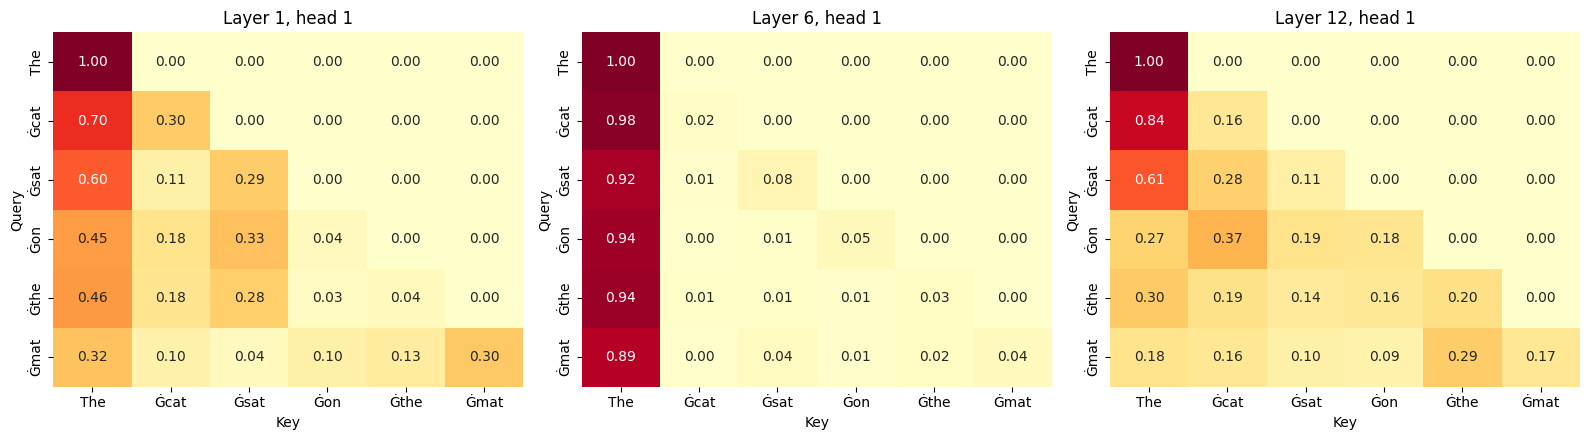

In [74]:
##Attention mechanisms, and how these models are trained.(heatmap)
#belt and braces version that als seet it on the config
model.config.output_attentions = True

text = "The cat sat on the mat"
inp = tokenizer(text, return_tensors="pt")
toks = tokenizer.convert_ids_to_tokens(inp["input_ids"][0])

with torch.no_grad():
    attn_out = model(**inp, output_attentions=True, return_dict=True)

assert len(attn_out.attentions) == 12, f"got {len(attn_out.attentions)} layers"
print("shape:", attn_out.attentions[0].shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, layer in zip(axes, [0, 5, 11]):
    a = attn_out.attentions[layer][0, 0].numpy()
    sns.heatmap(a, xticklabels=toks, yticklabels=toks, cmap="YlOrRd",
                annot=True, fmt=".2f", cbar=False, ax=ax)
    ax.set_title(f"Layer {layer+1}, head 1")
    ax.set_xlabel("Key"); ax.set_ylabel("Query")
plt.tight_layout(); plt.show()

In [75]:
#Q, K, V computed manually
block = model.transformer.h[0]
pos = torch.arange(inp["input_ids"].shape[1])
h = model.transformer.wte(inp["input_ids"]) + model.transformer.wpe(pos)
h = block.ln_1(h)

qkv = block.attn.c_attn(h)                 # 768 -> 2304
q, k, v = qkv.split(768, dim=2)
d_k = 768 // 12
q1, k1, v1 = q[0,:,:d_k], k[0,:,:d_k], v[0,:,:d_k]

scores = (q1 @ k1.T) / math.sqrt(d_k)      # scaled dot product
mask = torch.triu(torch.ones_like(scores), diagonal=1).bool()
scores = scores.masked_fill(mask, float("-inf"))   # causal mask
weights = torch.softmax(scores, dim=-1)
output = weights @ v1

print("Manual attention weights:\n", weights.detach().numpy().round(2))
print("\nOutput shape:", tuple(output.shape))

Manual attention weights:
 [[1.   0.   0.   0.   0.   0.  ]
 [0.7  0.3  0.   0.   0.   0.  ]
 [0.6  0.11 0.29 0.   0.   0.  ]
 [0.45 0.18 0.33 0.04 0.   0.  ]
 [0.46 0.18 0.28 0.03 0.04 0.  ]
 [0.32 0.1  0.04 0.1  0.13 0.3 ]]

Output shape: (6, 64)


In [76]:
#The training objective
ids = inp["input_ids"]
with torch.no_grad():
    out = model(ids, labels=ids)     # labels shifted internally

print(f"Cross-entropy loss: {out.loss.item():.4f}")
print(f"Perplexity:         {torch.exp(out.loss).item():.2f}\n")

logits = out.logits[0]
print(f"{'context ends with':<20} {'predicted':<14} {'actual'}")
for i in range(len(toks) - 1):
    pred = tokenizer.decode(logits[i].argmax())
    print(f"{toks[i]:<20} {pred:<14} {toks[i+1]}")

Cross-entropy loss: 4.8504
Perplexity:         127.79

context ends with    predicted      actual
The                  
              Ġcat
Ġcat                  was           Ġsat
Ġsat                  on            Ġon
Ġon                   the           Ġthe
Ġthe                  floor         Ġmat


In [77]:
#Loss on real texxt vs nonsense
def load_gutenberg(book_id):
    url = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}); r.raise_for_status()
    t = r.text
    s = re.search(r"\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*", t)
    e = re.search(r"\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*", t)
    return t[s.end():e.start()].strip() if s and e else t.strip()

book = load_gutenberg(1342)
open("pride.txt", "w").write(book)      # cache to avoid rate limits

def perplexity(txt):
    enc = tokenizer(txt, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        return torch.exp(model(**enc, labels=enc["input_ids"]).loss).item()

print(f"Pride and Prejudice: {perplexity(book[5000:8000]):.2f}")
print(f"Shuffled nonsense:   {perplexity('zxq blorp ktrm vlan wug pfth nexil bram'):.2f}")

Pride and Prejudice: 257.74
Shuffled nonsense:   899.80


In [78]:
#Generation(pretrained but unaligned)
def generate_text(prompt, max_new_tokens=100, temperature=0.8):
    enc = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens,
                             do_sample=True, temperature=temperature, top_p=0.9,
                             pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0], skip_special_tokens=True)

for temp in [0.3, 0.8, 1.3]:
    set_seed(42)
    print(f"=== temperature = {temp} ===")
    print(generate_text("It is a truth universally acknowledged,", 60, temp), "\n")

=== temperature = 0.3 ===
It is a truth universally acknowledged, that the world is not a place where the human race is to be found. The world is a place where the human race is to be found. The world is a place where the human race is to be found. The world is a place where the human race is to be found. The world 

=== temperature = 0.8 ===
It is a truth universally acknowledged, that there are a number of different ways that the government is able to control and manipulate the economy, and that this is largely the result of the power of government power and the role of the state.

The same is true of how the state and the Federal Reserve are operating. As we have 

=== temperature = 1.3 ===
It is a truth universally acknowledged, that there was a vast economic war being waged, between Israel and the Arabs, between the states and states. The state is the central body of power for both political and economic policy. Thus, it is necessary for this purpose, a single government to form, 

In [79]:
#Training: Implement a basic text generation model using Python libraries such as TensorFlow (Keras, or PyTorch).
#1. data preparation
import torch, torch.nn as nn, numpy as np

text = open("pride.txt").read()[:200_000]   # cap for speed
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(chars)

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print(f"Characters: {len(text):,} | Vocab: {vocab_size}")

Characters: 200,000 | Vocab: 89


In [80]:
#2. Batching
SEQ_LEN, BATCH = 128, 64
device = "cuda" if torch.cuda.is_available() else "cpu"

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - SEQ_LEN - 1, (BATCH,))
    x = torch.stack([d[i:i+SEQ_LEN] for i in ix])
    y = torch.stack([d[i+1:i+SEQ_LEN+1] for i in ix])   # targets shifted by one
    return x.to(device), y.to(device)

In [81]:
#3. Model
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, emb=128, hidden=256, layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb)
        self.lstm  = nn.LSTM(emb, hidden, layers, batch_first=True, dropout=0.2)
        self.fc    = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        x = self.embed(x)
        out, state = self.lstm(x, state)
        return self.fc(out), state

model_lstm = CharLSTM(vocab_size).to(device)
print(f"Parameters: {sum(p.numel() for p in model_lstm.parameters()):,}")

Parameters: 955,865


In [83]:
#Training loop
opt = torch.optim.AdamW(model_lstm.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()
history = []

for step in range(500):
    x, y = get_batch("train")
    logits, _ = model_lstm(x)
    loss = loss_fn(logits.reshape(-1, vocab_size), y.reshape(-1))

    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
    opt.step()

    if step % 200 == 0:
        model_lstm.eval()
        with torch.no_grad():
            xv, yv = get_batch("val")
            lv, _ = model_lstm(xv)
            val = loss_fn(lv.reshape(-1, vocab_size), yv.reshape(-1)).item()
        model_lstm.train()
        history.append((step, loss.item(), val))
        print(f"step {step:>4} | train {loss.item():.3f} | val {val:.3f}")

step    0 | train 1.989 | val 2.240
step  200 | train 1.385 | val 1.452
step  400 | train 1.265 | val 1.326


In [84]:
#5. Generate
def generate(seed="It is a truth", length=400, temperature=0.8):
    model_lstm.eval()
    idx = torch.tensor([[stoi[c] for c in seed]], device=device)
    state, out = None, seed
    with torch.no_grad():
        logits, state = model_lstm(idx, state)
        for _ in range(length):
            probs = torch.softmax(logits[0, -1] / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1)
            out += itos[nxt.item()]
            logits, state = model_lstm(nxt.unsqueeze(0), state)
    return out

for t in [0.4, 0.8, 1.2]:
    print(f"--- temperature {t} ---\n{generate(temperature=t, length=250)}\n")

--- temperature 0.4 ---
It is a truth her attention of morning to Mr. Darcy was something to see the discorss of his five into the sort of love a sisters of the room, and
a screen of the evening and great seems to have the country in the same more to be a good of the particular to any s

--- temperature 0.8 ---
It is a truth the officers,
of made persons was, me, the rest really defice to assudie, accopid to drelbour of that about a looked nothing, and she expected to his answards of being not the same to the ladies of his fave the appleasing a moments of Miss
Bingley a

--- temperature 1.2 ---
It is a truth.

Elizabeth, leing her hope on; but is neighclewn, on
which despriviation therefare, indeed,--when a way to see your to myself
playing when
ngeguest; boind it is mittle
partw you. She likely determs
obsext to Estable your intricule Bingley answered 



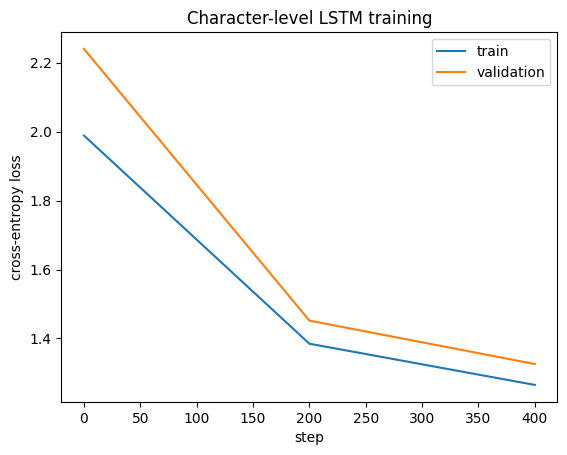

In [85]:
#Loss Curv for the writeup
s, tr, va = zip(*history)
plt.plot(s, tr, label="train"); plt.plot(s, va, label="validation")
plt.xlabel("step"); plt.ylabel("cross-entropy loss"); plt.legend()
plt.title("Character-level LSTM training"); plt.show()

#Part 3: Application Demonstration:
- Describe and implement a small practical example demonstrating a content creation application using your trained model.

In [86]:
#Mini GPT trained from scratch
#1. Config one attention head
import torch, torch.nn as nn, torch.nn.functional as F

SEQ_LEN, BATCH = 128, 64
N_EMB, N_HEAD, N_LAYER, DROPOUT = 192, 6, 4, 0.1
device = "cuda" if torch.cuda.is_available() else "cpu"

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(N_EMB, head_size, bias=False)
        self.query = nn.Linear(N_EMB, head_size, bias=False)
        self.value = nn.Linear(N_EMB, head_size, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(SEQ_LEN, SEQ_LEN)))
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        k, q, v = self.key(x), self.query(x), self.value(x)
        w = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5      # scaled dot product
        w = w.masked_fill(self.mask[:T, :T] == 0, float("-inf"))  # causal mask
        w = self.drop(F.softmax(w,dim=-1))
        return w @ v

In [87]:
#2. Multi-headm feed-forward, block
class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(n_head)])
        self.proj  = nn.Linear(N_EMB, N_EMB)
        self.drop  = nn.Dropout(DROPOUT)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.drop(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_EMB, 4 * N_EMB), nn.GELU(),
            nn.Linear(4 * N_EMB, N_EMB), nn.Dropout(DROPOUT))

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = MultiHeadAttention(N_HEAD, N_EMB // N_HEAD)
        self.ff   = FeedForward()
        self.ln1, self.ln2 = nn.LayerNorm(N_EMB), nn.LayerNorm(N_EMB)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual connection
        x = x + self.ff(self.ln2(x))     # residual connection
        return x

In [88]:
#3. Full model
class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, N_EMB)
        self.pos_emb = nn.Embedding(SEQ_LEN, N_EMB)
        self.blocks  = nn.Sequential(*[Block() for _ in range(N_LAYER)])
        self.ln_f    = nn.LayerNorm(N_EMB)
        self.head    = nn.Linear(N_EMB, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        x = self.ln_f(self.blocks(x))
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -SEQ_LEN:])          # crop to context window
            probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

gpt = MiniGPT().to(device)
print(f"Parameters: {sum(p.numel() for p in gpt.parameters()):,}")

Parameters: 1,836,377


In [89]:
#4. Train
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - SEQ_LEN - 1, (BATCH,))
    x = torch.stack([d[i:i+SEQ_LEN] for i in ix])
    y = torch.stack([d[i+1:i+SEQ_LEN+1] for i in ix])
    return x.to(device), y.to(device)

opt = torch.optim.AdamW(gpt.parameters(), lr=3e-4)
history = []

for step in range(3000):
    x, y = get_batch("train")
    _, loss = gpt(x, y)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    if step % 300 == 0:
        gpt.eval()
        xv, yv = get_batch("val")
        _, vloss = gpt(xv, yv)
        gpt.train()
        history.append((step, loss.item(), vloss.item()))
        print(f"step {step:>4} | train {loss.item():.3f} | val {vloss.item():.3f}")

step    0 | train 4.715 | val 4.476
step  300 | train 2.326 | val 2.392
step  600 | train 1.930 | val 1.966
step  900 | train 1.746 | val 1.711
step 1200 | train 1.591 | val 1.533
step 1500 | train 1.423 | val 1.435
step 1800 | train 1.388 | val 1.402
step 2100 | train 1.298 | val 1.349
step 2400 | train 1.280 | val 1.285
step 2700 | train 1.209 | val 1.370


In [90]:
#5. Generate and inspect
seed = "It is a truth"
idx = torch.tensor([[stoi[c] for c in seed]], device=device)
out = gpt.generate(idx, 400, temperature=0.8)
print("".join(itos[i] for i in out[0].tolist()))

It is a truth occasion which guiled is to be two you call
prospect on ides in a fetcaring the happeness of her. It should
not have give him.”

“Mr. Bennet and I doubt quijust with him sure of them. Firster more
couptenders exception to gentlemens, while the leave all a
glened, to assure your well at the is not some
sown one often such the greates of seitude con. And be did not a woman a
conversation
one of pit
